# Temporal Fusion Transformer (TFT) — PM2.5 Forecasting
This notebook trains a TFT model on station data and evaluates it with multiple metrics:
**RMSE, MSE, R², and F1-Score** (via a PM2.5 threshold classification).

## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import torch
import lightning.pytorch as pl
from lightning.pytorch.trainer import Trainer
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.metrics import QuantileLoss
from pytorch_forecasting.data.encoders import GroupNormalizer
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping
from lightning.pytorch.loggers import CSVLogger
import matplotlib.pyplot as plt
import os
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

%matplotlib inline

c:\Users\ssupa\Code\Pm2.5_forcast\model\TFT\venv_tft\Lib\site-packages\pytorch_forecasting\models\base\_base_model.py:30: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


## 2. Load & Prepare Data

In [4]:
df = pd.read_csv("05T_cleaned_features.csv")

df = df.rename(columns={
    "Wind Speed": "Wind_Speed",
    "Temp.": "Temp",
    "Humi.": "Humi",
    "Pres.": "Pres",
    "Prec.": "Prec",
    "Vis.": "Vis",
    "PM2.5": "PM25",
    "PM2.5_lag1": "PM25_lag1",
    "PM2.5_lag2": "PM25_lag2",
    "PM2.5_lag3": "PM25_lag3",
    "PM2.5_lag7": "PM25_lag7",
    "PM2.5_lag14": "PM25_lag14",
    "PM2.5_lag30": "PM25_lag30",
    "PM2.5_rollmean3": "PM25_rollmean3",
    "PM2.5_rollstd3": "PM25_rollstd3",
    "PM2.5_rollmean7": "PM25_rollmean7",
    "PM2.5_rollstd7": "PM25_rollstd7",
    "PM2.5_rollmean14": "PM25_rollmean14",
    "PM2.5_rollstd14": "PM25_rollstd14",
    "Wind Dir_sin": "Wind_Dir_sin",
    "Wind Dir_cos": "Wind_Dir_cos",
    "Prec._lag1": "Prec_lag1",
    "Prec._lag2": "Prec_lag2",
    "Prec._lag3": "Prec_lag3",
    "Prec._lag7": "Prec_lag7",
    "Prec._lag14": "Prec_lag14",
    "Prec._rollsum3": "Prec_rollsum3",
    "Prec._rollmean3": "Prec_rollmean3",
    "Prec._rollsum7": "Prec_rollsum7",
    "Prec._rollmean7": "Prec_rollmean7",
    "Prec._rollsum14": "Prec_rollsum14",
    "Prec._rollmean14": "Prec_rollmean14",
})

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print(f"Rows before dropna: {len(df)}")
df = df.dropna().reset_index(drop=True)
print(f"Rows after dropna:  {len(df)}")

df.head()

Rows before dropna: 2064
Rows after dropna:  2034


,Date,Wind_Speed,Temp,Humi,heatidx,Pres,Prec,Vis,PM25,year,...,Prec_lag2,Prec_lag3,Prec_lag7,Prec_lag14,Prec_rollsum3,Prec_rollmean3,Prec_rollsum7,Prec_rollmean7,Prec_rollsum14,Prec_rollmean14
0,2018-05-10,3.1,30.2,79.8,38.3,1007.0,0.0,19838,10.0,2018,...,0.0,0.4,0.8,2.8,0.4,0.133333,16.4,2.342857,225.8,16.128571
1,2018-05-11,2.2,27.9,85.4,32.8,1007.3,0.6,16028,14.0,2018,...,0.0,0.0,0.0,14.4,0.0,0.000000,15.6,2.228571,223.0,15.928571
2,2018-05-12,2.5,30.0,78.3,37.3,1006.9,0.0,16961,21.0,2018,...,0.0,0.0,0.0,75.8,0.6,0.200000,16.2,2.314286,209.2,14.942857
3,2018-05-13,2.2,29.8,79.5,36.9,1007.1,0.2,17802,22.0,2018,...,0.6,0.0,15.2,11.6,0.6,0.200000,16.2,2.314286,133.4,9.528571
4,2018-05-14,1.7,27.9,86.8,32.8,1006.5,13.8,12865,18.0,2018,...,0.0,0.6,0.4,92.2,0.8,0.266667,1.2,0.171429,122.0,8.714286


## 3. Feature Engineering

In [5]:
# Calendar features
df['month'] = df['Date'].dt.month
df['day_of_week'] = df['Date'].dt.dayofweek.astype(str)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# TFT requirements
df['time_idx'] = np.arange(len(df))
df['group_id'] = "station_05T"

print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['Date'].min()} → {df['Date'].max()}")
df.describe()

Dataset shape: (2034, 45)
Date range: 2018-05-10 00:00:00 → 2024-09-27 00:00:00


,Date,Wind_Speed,Temp,Humi,heatidx,Pres,Prec,Vis,PM25,year,...,Prec_lag7,Prec_lag14,Prec_rollsum3,Prec_rollmean3,Prec_rollsum7,Prec_rollmean7,Prec_rollsum14,Prec_rollmean14,month,time_idx
count,2034,2034.000000,2034.000000,2034.000000,2034.000000,2034.000000,2034.000000,2034.000000,2034.000000,2034.000000,...,2034.000000,2034.000000,2034.000000,2034.000000,2034.000000,2034.000000,2034.000000,2034.000000,2034.000000,2034.000000
mean,2021-08-04 16:57:20.707964672,3.078368,28.996460,73.545034,33.820206,1008.293854,5.379302,16901.306293,22.484882,2021.085546,...,5.344592,5.404867,16.120600,5.373533,37.523353,5.360479,75.231465,5.373676,6.608653,1016.500000
min,2018-05-10 00:00:00,0.100000,20.900000,0.000000,20.900000,999.600000,0.000000,0.000000,4.000000,2018.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,2019-11-19 06:00:00,2.300000,27.900000,67.000000,31.100000,1006.300000,0.000000,16076.000000,13.000000,2019.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.800000,0.057143,4.000000,508.250000
50%,2021-10-22 12:00:00,2.900000,29.050000,74.600000,34.000000,1008.100000,0.000000,17801.000000,18.400000,2021.000000,...,0.000000,0.000000,0.400000,0.133333,15.400000,2.200000,45.500000,3.250000,7.000000,1016.500000
75%,2023-05-07 18:00:00,3.700000,30.100000,80.500000,36.500000,1010.400000,1.400000,19624.500000,28.275000,2023.000000,...,1.200000,1.200000,19.800000,6.600000,54.750000,7.821429,115.000000,8.214286,9.000000,1524.750000
max,2024-09-27 00:00:00,6.200000,34.000000,97.100000,45.300000,1017.100000,166.200000,20000.000000,98.000000,2024.000000,...,166.200000,166.200000,218.200000,72.733333,367.000000,52.428571,507.800000,36.271429,12.000000,2033.000000
std,NaN,0.974139,1.866195,10.025361,4.005333,2.836998,15.145882,3948.872517,13.162239,1.973648,...,15.126758,15.300910,30.277512,10.092504,54.033412,7.719059,90.849587,6.489256,3.457314,587.309544


## 4. Define Variable Groups & Create TimeSeriesDataSet

In [6]:
# Known in advance (calendar / time features)
known_reals = ["time_idx", "month_sin", "month_cos"]
known_categoricals = ["day_of_week"]

# Unknown at forecast time (observed weather & lag features)
unknown_reals = [
    "PM25_lag1",
    "dayofyear_cos",
    "Pres",
    "Humi",
    "Vis",
    "Wind_Speed",
    "PM25_rollmean14",
    "dayofyear_sin",
    "heatidx",
    "Prec_rollsum14",
    "Wind_Dir_cos",
    "Wind_Dir_sin",
]

max_encoder_length = 30   # look-back window
max_prediction_length = 1  # forecast horizon

training_cutoff = int(df["time_idx"].max() * 0.8)
print(f"Training cutoff time_idx: {training_cutoff}  (total: {df['time_idx'].max()})")

training = TimeSeriesDataSet(
    df[lambda x: x.time_idx <= training_cutoff],
    time_idx="time_idx",
    target="PM25",
    group_ids=["group_id"],
    min_encoder_length=max_encoder_length,
    max_encoder_length=max_encoder_length,
    min_prediction_length=max_prediction_length,
    max_prediction_length=max_prediction_length,
    static_categoricals=["group_id"],
    time_varying_known_categoricals=known_categoricals,
    time_varying_known_reals=known_reals,
    time_varying_unknown_reals=unknown_reals,
    target_normalizer=GroupNormalizer(
        groups=["group_id"], transformation="softplus"
    ),
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
)

validation = TimeSeriesDataSet.from_dataset(
    training,
    df,
    min_prediction_idx=training_cutoff + 1,
    stop_randomization=True,
)

batch_size = 64
train_dataloader = training.to_dataloader(train=True, batch_size=batch_size, num_workers=0)
val_dataloader = validation.to_dataloader(train=False, batch_size=batch_size * 10, num_workers=0)

print(f"Training samples:   {len(training)}")
print(f"Validation samples: {len(validation)}")

Training cutoff time_idx: 1626  (total: 2033)
Training samples:   1597
Validation samples: 407


## 5. Build TFT Model

In [7]:
tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=1e-3,
    hidden_size=64,
    attention_head_size=4,
    dropout=0.2,
    hidden_continuous_size=32,
    output_size=7,             # 7 quantiles
    loss=QuantileLoss(),
    optimizer="adamw",
    weight_decay=1e-2,
    reduce_on_plateau_patience=5,
    reduce_on_plateau_reduction=10,
    reduce_on_plateau_min_lr=1e-6,
)

print(f"Number of parameters in network: {tft.size()/1e3:.1f}k")

Number of parameters in network: 374.8k


c:\Users\ssupa\Code\Pm2.5_forcast\model\TFT\venv_tft\Lib\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
c:\Users\ssupa\Code\Pm2.5_forcast\model\TFT\venv_tft\Lib\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.


## 6. Train the Model

In [8]:
logger = CSVLogger("logs", name="05T_model_v3")

checkpoint_callback = ModelCheckpoint(
    monitor="val_loss",
    mode="min",
    save_top_k=1,
    filename="best-checkpoint",
)

# early_stop_callback = EarlyStopping(
#     monitor="val_loss",
#     min_delta=1e-4,
#     patience=20,
#     verbose=True,
#     mode="min",
# )

trainer = Trainer(
    max_epochs=200,
    accelerator="cuda" if torch.cuda.is_available() else "cpu",
    devices=1,
    gradient_clip_val=0.1,
    logger=logger,
    callbacks=[checkpoint_callback],
    enable_progress_bar=True,
)

trainer.fit(
    tft,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
)

best_model_path = trainer.checkpoint_callback.best_model_path
print(f"\nBest model saved at: {best_model_path}")

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.



   | Name                               | Type                            | Params | Mode  | FLOPs
--------------------------------------------------------------------------------------------------------
0  | loss                               | QuantileLoss                    | 0      | train | 0    
1  | logging_metrics                    | ModuleList                      | 0      | train | 0    
2  | input_embeddings                   | MultiEmbedding                  | 36     | train | 0    
3  | prescalers                         | ModuleDict                      | 1.2 K  | train | 0    
4  | static_variable_selection          | VariableSelectionNetwork        | 20.8 K | train | 0    
5  | encoder_variable_selection         | VariableSelectionNetwork        | 118 K  | train | 0    
6  | decoder_variable_selection         | VariableSelectionNetwork        | 28.2 K | train | 0    
7  | static_context_variable_selection  | GatedResidualNetwork            | 16.8 K | train | 0    
8  

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\ssupa\Code\Pm2.5_forcast\model\TFT\venv_tft\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\ssupa\Code\Pm2.5_forcast\model\TFT\venv_tft\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


c:\Users\ssupa\Code\Pm2.5_forcast\model\TFT\venv_tft\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
c:\Users\ssupa\Code\Pm2.5_forcast\model\TFT\venv_tft\Lib\site-packages\lightning\pytorch\loops\fit_loop.py:317: The number of training batches (24) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Epoch 199: 100%|██████████| 24/24 [00:04<00:00,  5.53it/s, v_num=0, train_loss_step=1.940, val_loss=2.950, train_loss_epoch=1.920]

`Trainer.fit` stopped: `max_epochs=200` reached.


Epoch 199: 100%|██████████| 24/24 [00:04<00:00,  5.53it/s, v_num=0, train_loss_step=1.940, val_loss=2.950, train_loss_epoch=1.920]

Best model saved at: logs\05T_model_v3\version_0\checkpoints\best-checkpoint.ckpt


## 7. Training & Validation Loss Plot

Loading metrics from: logs\05T_model_v3\version_0/metrics.csv


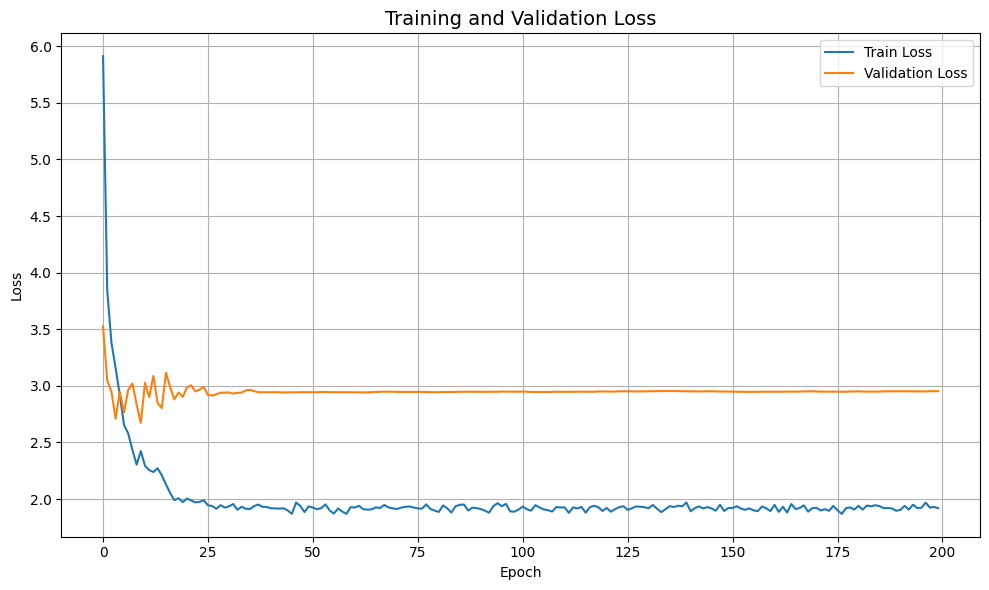

In [9]:
metrics_path = f"{trainer.logger.log_dir}/metrics.csv"
print(f"Loading metrics from: {metrics_path}")
metrics = pd.read_csv(metrics_path)
epoch_metrics = metrics.groupby("epoch").mean()

fig, ax = plt.subplots(figsize=(10, 6))

if 'train_loss_epoch' in epoch_metrics.columns:
    ax.plot(epoch_metrics.index, epoch_metrics['train_loss_epoch'], label='Train Loss')
elif 'train_loss' in epoch_metrics.columns:
    ax.plot(epoch_metrics.index, epoch_metrics['train_loss'], label='Train Loss')

if 'val_loss' in epoch_metrics.columns:
    ax.plot(epoch_metrics.index, epoch_metrics['val_loss'], label='Validation Loss')

ax.set_title('Training and Validation Loss', fontsize=14)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

## 8. Predictions on Validation Set

In [11]:
# Load best checkpoint
best_tft = TemporalFusionTransformer.load_from_checkpoint(best_model_path)

# Get actuals and predictions
actuals = torch.cat([y[0] for x, y in iter(val_dataloader)])
predictions = best_tft.predict(val_dataloader)

y_true = actuals.cpu().numpy().flatten()
y_pred = predictions.cpu().numpy().flatten()

print(f"y_true shape: {y_true.shape}")
print(f"y_pred shape: {y_pred.shape}")
print(f"y_true NaNs:  {np.isnan(y_true).any()}")
print(f"y_pred NaNs:  {np.isnan(y_pred).any()}")

c:\Users\ssupa\Code\Pm2.5_forcast\model\TFT\venv_tft\Lib\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
c:\Users\ssupa\Code\Pm2.5_forcast\model\TFT\venv_tft\Lib\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org

y_true shape: (407,)
y_pred shape: (407,)
y_true NaNs:  False
y_pred NaNs:  False


## 9. Regression Metrics — MSE, RMSE, MAE, R²

In [12]:
mse  = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)

print("=" * 45)
print("  Regression Metrics (Validation Set)")
print("=" * 45)
print(f"  MSE  : {mse:.4f}")
print(f"  RMSE : {rmse:.4f}")
print(f"  MAE  : {mae:.4f}")
print(f"  R²   : {r2:.4f}")
print("=" * 45)

  Regression Metrics (Validation Set)
  MSE  : 48.6309
  RMSE : 6.9736
  MAE  : 4.8656
  R²   : 0.6050


## 10. F1-Score (Threshold-based Classification)

PM2.5 > **37.5 µg/m³** is classified as **unhealthy** (Thailand AQI orange level).
We convert predictions & actuals into binary labels and compute the F1-score.

Threshold: PM2.5 > 37.5 µg/m³  →  Unhealthy (1)
F1-Score : 0.5366

              precision    recall  f1-score   support

      Normal       0.95      0.95      0.95       365
   Unhealthy       0.55      0.52      0.54        42

    accuracy                           0.91       407
   macro avg       0.75      0.74      0.74       407
weighted avg       0.90      0.91      0.91       407



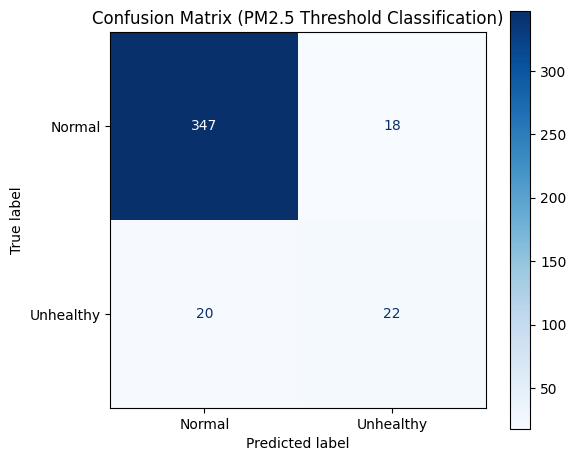

In [13]:
PM25_THRESHOLD = 37.5  # µg/m³ — adjust as needed

y_true_cls = (y_true > PM25_THRESHOLD).astype(int)
y_pred_cls = (y_pred > PM25_THRESHOLD).astype(int)

f1 = f1_score(y_true_cls, y_pred_cls)

print(f"Threshold: PM2.5 > {PM25_THRESHOLD} µg/m³  →  Unhealthy (1)")
print(f"F1-Score : {f1:.4f}\n")
print(classification_report(y_true_cls, y_pred_cls, target_names=["Normal", "Unhealthy"]))

# Confusion Matrix
cm = confusion_matrix(y_true_cls, y_pred_cls)
disp = ConfusionMatrixDisplay(cm, display_labels=["Normal", "Unhealthy"])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues")
ax.set_title("Confusion Matrix (PM2.5 Threshold Classification)")
plt.tight_layout()
plt.show()

## 11. Actual vs Predicted — Scatter Plot

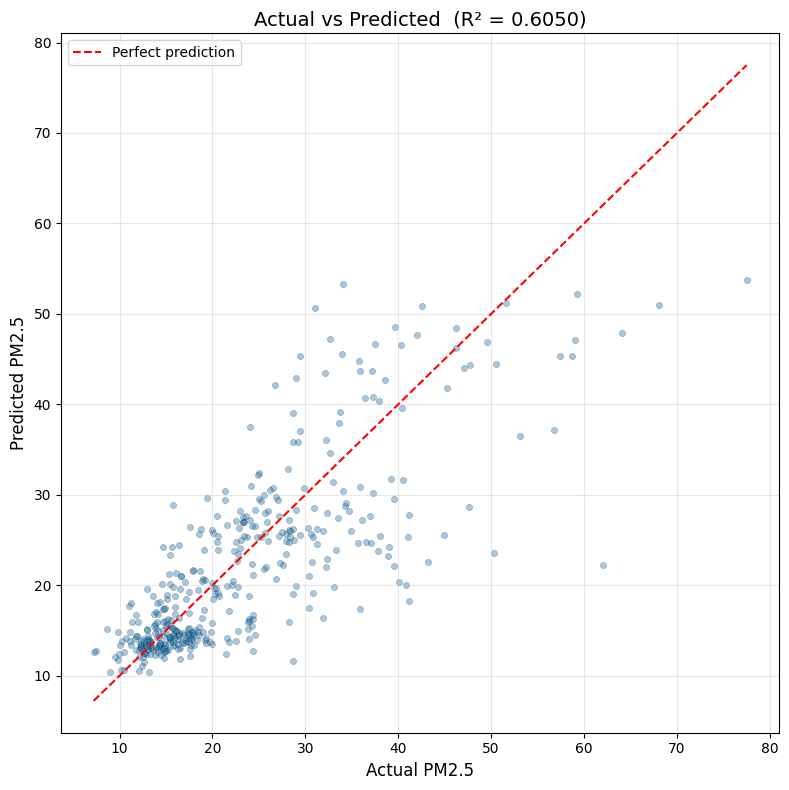

In [14]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_true, y_pred, alpha=0.4, edgecolors='k', linewidths=0.3, s=20)

# Perfect-prediction line
lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')

ax.set_xlabel('Actual PM2.5', fontsize=12)
ax.set_ylabel('Predicted PM2.5', fontsize=12)
ax.set_title(f'Actual vs Predicted  (R² = {r2:.4f})', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 12. Actual vs Predicted — Time Series Plot

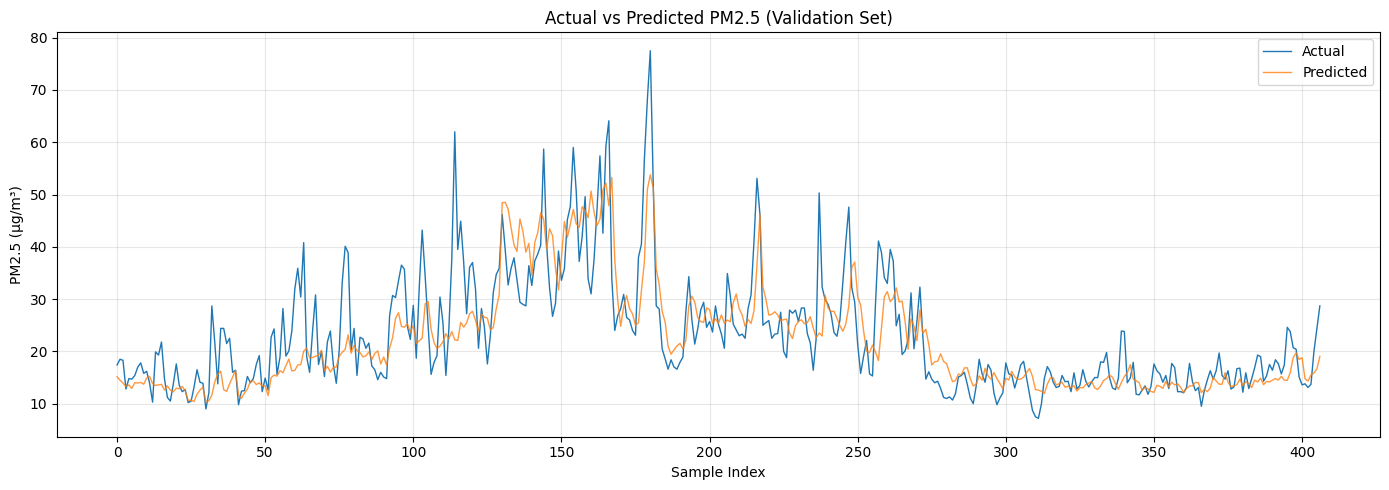

In [15]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(y_true, label='Actual', linewidth=1)
ax.plot(y_pred, label='Predicted', linewidth=1, alpha=0.8)
ax.set_xlabel('Sample Index')
ax.set_ylabel('PM2.5 (µg/m³)')
ax.set_title('Actual vs Predicted PM2.5 (Validation Set)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 13. Residual Distribution

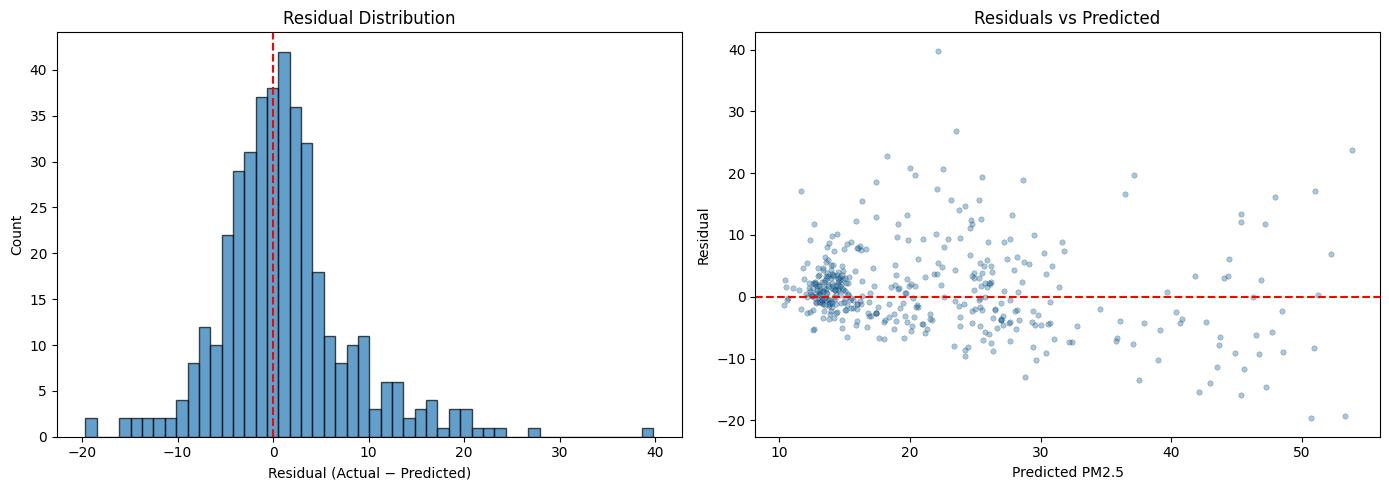

In [16]:
residuals = y_true - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(residuals, bins=50, edgecolor='k', alpha=0.7)
axes[0].axvline(0, color='r', linestyle='--')
axes[0].set_title('Residual Distribution')
axes[0].set_xlabel('Residual (Actual − Predicted)')
axes[0].set_ylabel('Count')

# Residual vs Predicted
axes[1].scatter(y_pred, residuals, alpha=0.4, s=15, edgecolors='k', linewidths=0.3)
axes[1].axhline(0, color='r', linestyle='--')
axes[1].set_title('Residuals vs Predicted')
axes[1].set_xlabel('Predicted PM2.5')
axes[1].set_ylabel('Residual')

plt.tight_layout()
plt.show()

## 14. Summary Table

In [ ]:
summary = pd.DataFrame({
    "Metric": ["MSE", "RMSE", "MAE", "R²"],
    "Value":  [f"{mse:.4f}", f"{rmse:.4f}", f"{mae:.4f}", f"{r2:.4f}"],
})
summary.style.hide(axis="index")

Metric,Value
MSE,48.6309
RMSE,6.9736
MAE,4.8656
R²,0.6050
F1-Score (threshold=37.5),0.5366
